# McDonald's atsiliepimų sentimentų analizė

Šiame užrašų bloknote parodomi pagrindiniai sentimentų analizės rezultatai ir modelių palyginimas, naudojant McDonald's klientų atsiliepimų duomenis.


Eilučių skaičius po valymo: 28578


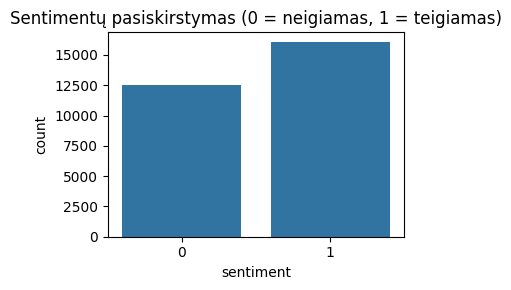


===== LogisticRegression =====
Accuracy: 0.9113
F1-score: 0.9213

Classification report:
              precision    recall  f1-score   support

           0     0.9021    0.8946    0.8983      2504
           1     0.9183    0.9243    0.9213      3212

    accuracy                         0.9113      5716
   macro avg     0.9102    0.9095    0.9098      5716
weighted avg     0.9112    0.9113    0.9113      5716



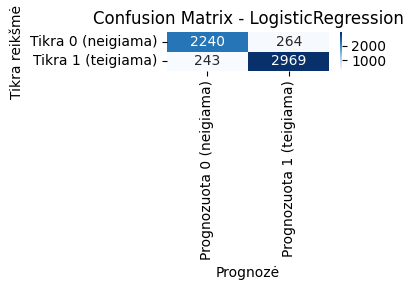


===== RandomForest =====
Accuracy: 0.9164
F1-score: 0.9254

Classification report:
              precision    recall  f1-score   support

           0     0.9017    0.9081    0.9049      2504
           1     0.9280    0.9228    0.9254      3212

    accuracy                         0.9164      5716
   macro avg     0.9148    0.9155    0.9151      5716
weighted avg     0.9165    0.9164    0.9164      5716



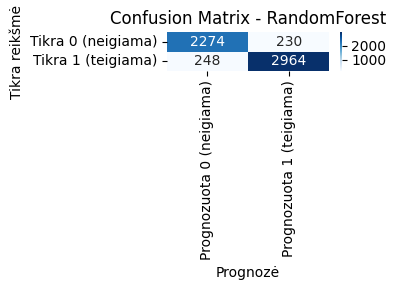


===== MLPClassifier =====
Accuracy: 0.9110
F1-score: 0.9216

Classification report:
              precision    recall  f1-score   support

           0     0.9090    0.8854    0.8970      2504
           1     0.9124    0.9309    0.9216      3212

    accuracy                         0.9110      5716
   macro avg     0.9107    0.9081    0.9093      5716
weighted avg     0.9109    0.9110    0.9108      5716



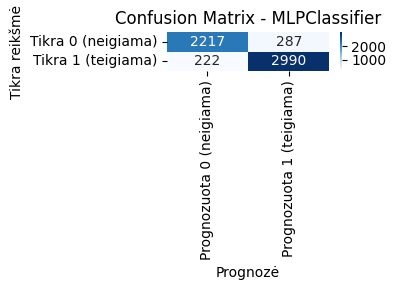


===== Modelių palyginimo lentelė (pagal F1-score) =====
                model  accuracy  f1_score
0        RandomForest  0.916375  0.925382
1       MLPClassifier  0.910952  0.921560
2  LogisticRegression  0.911302  0.921334


,model,accuracy,f1_score
0,RandomForest,0.916375,0.925382
1,MLPClassifier,0.910952,0.921560
2,LogisticRegression,0.911302,0.921334


In [1]:
# Importuojamos reikalingos funkcijos ir bibliotekos
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from train_models import (
    ensure_utf8_stdout,
    load_and_clean_data,
    vectorize_text,
    train_models,
    evaluate_models,
    add_needs_urgent_response_column,
)

ensure_utf8_stdout()

# 1. Duomenų įkėlimas ir papildomas valymas
df = load_and_clean_data("McDonald_s_Reviews_prepared.csv")
print(f"Eilučių skaičius po valymo: {len(df)}")

# 2. Sentimentų pasiskirstymas
plt.figure(figsize=(4, 3))
sns.countplot(x="sentiment", data=df)
plt.title("Sentimentų pasiskirstymas (0 = neigiamas, 1 = teigiamas)")
plt.tight_layout()
plt.show()

# 3. TF-IDF vektorizacija ir duomenų skaidymas
from sklearn.model_selection import train_test_split

X, y, vectorizer = vectorize_text(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Modelių mokymas ir vertinimas
models = train_models(X_train, y_train)
results_df = evaluate_models(models, X_train, X_test, y_train, y_test)
results_df


In [2]:
# 5. Verslo logika: `needs_urgent_response` ir keli pavyzdžiai
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
print(f"Geriausias modelis pagal F1-score: {best_model_name}")

df_with_flags = add_needs_urgent_response_column(df, best_model, vectorizer)
print("Pirmos 5 eilutės su `needs_urgent_response`:")
df_with_flags[["review", "sentiment", "needs_urgent_response"]].head()


Geriausias modelis pagal F1-score: RandomForest


Pirmos 5 eilutės su `needs_urgent_response`:


,review,sentiment,needs_urgent_response
0,Why does it look like someone spit on my food?...,0,0
1,It'd McDonalds. It is what it is as far as the...,1,0
2,Made a mobile order got to the speaker and che...,0,0
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,1,0
4,"I repeat my order 3 times in the drive thru, a...",0,0
